# Shot-level 오토인코더

**1행 = 사출 1회** (`Shot_Injection_HD{n}_P{m}` 의 0→1 전이).

사이클 단위 모델은 8초짜리 사이클을 숫자 하나로 요약하므로 그 안의 **개별 사출 이상**이
평균에 묻힌다. 이 모델은 사출 하나하나를 본다.

실측한 사출 거동 (P1 평균): 압력은 −9.4 떨어졌다 3~4틱에 회복, 유량은 +150 상승.
딥이 유독 깊거나 회복이 느리면 노즐·밸브 이상을 의심할 수 있다.

In [1]:
import os, sys
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd, torch, joblib
import torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import extract_cycle_features, PUMP_MAP
from Cycle_Normalizer import ResidualNormalizer, NORMALIZE_SPECS, SUFFIX
from Shot_AE_Model import ShotAutoencoder

ENV_PATH = os.path.join(ROOT_DIR, ".env")

# 추석 연휴(9/24~9/26)는 전 펌프 무가동이라 9/23 생산 종료로 끊는다
TRAIN_START, TRAIN_END = "2026-09-10T07:00:00Z", "2026-09-18T07:00:00Z"
VALID_START, VALID_END = "2026-09-18T07:00:00Z", "2026-09-19T07:00:00Z"
TEST_START,  TEST_END  = "2026-09-20T19:00:00Z", "2026-09-23T18:00:00Z"

In [2]:
def train_ae(X_train, X_valid, model_path, seed=42, epochs=400, patience=40, verbose=20, bottleneck=8):
    """v3 와 동일한 학습 방식 (lr 5e-4 + ReduceLROnPlateau + Early Stopping)."""
    torch.manual_seed(seed)
    model = ShotAutoencoder(input_dim=X_train.shape[1], bottleneck=bottleneck)
    crit = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=0.0005)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10)
    dl = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(X_train)),
                    batch_size=64, shuffle=True)
    vx = torch.FloatTensor(X_valid)
    best, best_ep, wait, hist = float("inf"), 0, 0, []
    for ep in range(1, epochs + 1):
        model.train(); tr = 0.0
        for xb, yb in dl:
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step(); tr += loss.item()
        tr /= len(dl)
        model.eval()
        with torch.no_grad():
            va = crit(model(vx), vx).item()
        sch.step(va); hist.append((ep, tr, va))
        if va < best - 1e-5:
            best, best_ep, wait = va, ep, 0
            torch.save(model.state_dict(), model_path)
        else:
            wait += 1
        if verbose and (ep % verbose == 0 or ep == 1):
            print(f"   epoch {ep:03d} | train {tr:.4f} | valid {va:.4f}"
                  + ("  *best*" if best_ep == ep else ""))
        if wait >= patience:
            break
    model.load_state_dict(torch.load(model_path, weights_only=True))
    return model, best, best_ep, hist


def recon(model, X):
    model.eval()
    with torch.no_grad():
        t = torch.FloatTensor(X); pf = ((t - model(t)) ** 2).numpy()
    return pf.mean(axis=1), pf

In [3]:
from Shot_Feature_Extractor import (extract_shot_features, SHOT_FEATURE_COLS,
                                   SHOT_NORMALIZE_SPECS)

PUMP_ID = "P1"
info = PUMP_MAP[PUMP_ID]
HEAD, SLOT = info["head"], info["slot"]
MODEL_DIR = os.path.join(os.getcwd(), "models_shot"); os.makedirs(MODEL_DIR, exist_ok=True)

TAGS = [f"Pump_BuildUp_{PUMP_ID}", f"g_s_SV_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
        f"Scale_Out___PT_{PUMP_ID}", f"Shot_Injection_{HEAD}_P{SLOT}", f"Hz_Out_{PUMP_ID}", "AL_Line_Bit"]

ex = LogExtractor(env_path=ENV_PATH)

def build(a, b, label):
    raw = ex.get_data(start_time=a, end_time=b, target_tags=TAGS)
    s = extract_shot_features(raw, PUMP_ID)
    print(f"[{label}] raw {len(raw):,}행 -> 사출 {len(s):,}건 (제외 {int(s['Excluded'].sum())})")
    return s

shot_tr = build(TRAIN_START, TRAIN_END, "Train")
shot_va = build(VALID_START, VALID_END, "Valid")
shot_te = build(TEST_START,  TEST_END,  "Test")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-10T07:00:00+00:00 ~ 2026-09-18T07:00:00+00:00
   태그 7개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-10T06:50:00Z ~ 2026-09-10T12:50:00Z ... 

38211행
📦 [Chunk] 2026-09-10T12:50:00Z ~ 2026-09-10T18:50:00Z ... 

33994행
📦 [Chunk] 2026-09-10T18:50:00Z ~ 2026-09-11T00:50:00Z ... 

35134행
📦 [Chunk] 2026-09-11T00:50:00Z ~ 2026-09-11T06:50:00Z ... 

37061행
📦 [Chunk] 2026-09-11T06:50:00Z ~ 2026-09-11T12:50:00Z ... 

...

37787행
📦 [Chunk] 2026-09-23T06:50:00Z ~ 2026-09-23T12:50:00Z ... 

38173행
📦 [Chunk] 2026-09-23T12:50:00Z ~ 2026-09-23T18:00:00Z ... 

29696행


✅ 통합 완료 — 425001행 × 8컬럼


[Test] raw 425,001행 -> 사출 9,390건 (제외 174)


In [4]:
def clean(s, drop_excluded=True):
    out = s[~s["Excluded"]] if drop_excluded else s.copy()
    return out.dropna(subset=SHOT_FEATURE_COLS)

tr, va, te = clean(shot_tr), clean(shot_va), clean(shot_te, False)
print(f"Train {len(tr):,} / Valid {len(va):,} / Test {len(te):,}")

# 시작 조건에 끌려다니는 딥 크기 / 유량 상승폭을 표준화 잔차로
norm = ResidualNormalizer(SHOT_NORMALIZE_SPECS)
norm.fit(tr)
tr, va, te = norm.transform(tr), norm.transform(va), norm.transform(te)
joblib.dump(norm, os.path.join(MODEL_DIR, f"normalizer_{PUMP_ID}.pkl"))
print()
print(norm.report(tr).to_string(index=False))

FEATS = [c for c in SHOT_FEATURE_COLS if c not in SHOT_NORMALIZE_SPECS] + \
        [t + SUFFIX for t in SHOT_NORMALIZE_SPECS]
print(f"\n모델 입력 {len(FEATS)}개: {FEATS}")

Train 21,407 / Valid 2,949 / Test 9,390

          피처               기준변수  원본 상관  정규화 후 상관  정규화 후 평균  정규화 후 표준편차
 PT_Dip_Size PT_Baseline_Before  0.292    -0.010     0.007       1.696
FT_Rise_Size FT_Baseline_Before -0.798     0.046     0.004       1.000

모델 입력 10개: ['PT_Baseline_Before', 'FT_Baseline_Before', 'Hz_at_Shot', 'DeltaP_over_Q_at_Shot', 'SV_at_Shot', 'PT_Dip_At_Sec', 'PT_Recovery_Sec', 'Inj_Duration_Sec', 'PT_Dip_Size_z', 'FT_Rise_Size_z']


In [5]:
scaler = StandardScaler()
Xtr = scaler.fit_transform(tr[FEATS]); Xva = scaler.transform(va[FEATS]); Xte = scaler.transform(te[FEATS])
joblib.dump(scaler, os.path.join(MODEL_DIR, f"scaler_{PUMP_ID}.pkl"))
print(Xtr.shape, Xva.shape, Xte.shape)

# Shot 전용 구조(10 -> 8 -> 5 -> 3 -> 5 -> 8 -> 10). 병목은 입력의 1/3.
BOTTLENECK = 3
model, best, best_ep, hist = train_ae(Xtr, Xva, os.path.join(MODEL_DIR, f"autoencoder_{PUMP_ID}.pth"),
                                      bottleneck=BOTTLENECK)
print(f"\nbest Valid Loss {best:.4f} (epoch {best_ep})")

(21407, 10) (2949, 10) (9390, 10)


   epoch 001 | train 1.0270 | valid 0.7968  *best*


   epoch 020 | train 0.2279 | valid 0.1551  *best*


   epoch 040 | train 0.1855 | valid 0.1521


   epoch 060 | train 0.1673 | valid 0.1567



best Valid Loss 0.1507 (epoch 34)


In [6]:
tr_err, tr_pf = recon(model, Xtr)
te_err, te_pf = recon(model, Xte)
va_err, _ = recon(model, Xva)
TH = float(np.percentile(tr_err, 99))
print(f"임계치 (Train 99퍼센타일): {TH:.4f}\n")
for n, e in [("Train", tr_err), ("Valid", va_err), ("Test", te_err)]:
    print(f"{n:6s} | 평균 {e.mean():.4f} | 최대 {e.max():.4f} | 초과 {int((e>TH).sum()):,}건 ({(e>TH).mean()*100:.2f}%)")

res = te.copy(); res["Recon_Error"] = te_err
res.to_pickle(os.path.join(MODEL_DIR, f"scored_test_{PUMP_ID}.pkl"))

print("\n피처별 평균 재구성오차")
print(pd.Series(tr_pf.mean(axis=0), index=FEATS).sort_values().to_string())
print("\n이상 건에서의 평균 기여도")
am = te_err > TH
print(pd.Series((te_pf/te_pf.sum(axis=1,keepdims=True)*100)[am].mean(axis=0),
                index=FEATS).sort_values(ascending=False).round(1).to_string())

임계치 (Train 99퍼센타일): 1.1824

Train  | 평균 0.1924 | 최대 1016.2334 | 초과 215건 (1.00%)
Valid  | 평균 0.1507 | 최대 10.2467 | 초과 35건 (1.19%)
Test   | 평균 0.1416 | 최대 18.1157 | 초과 63건 (0.67%)

피처별 평균 재구성오차
SV_at_Shot               0.037764
Hz_at_Shot               0.037936
FT_Baseline_Before       0.051848
FT_Rise_Size_z           0.060281
PT_Baseline_Before       0.127152
PT_Recovery_Sec          0.146640
DeltaP_over_Q_at_Shot    0.149839
Inj_Duration_Sec         0.366613
PT_Dip_At_Sec            0.437759
PT_Dip_Size_z            0.508080

이상 건에서의 평균 기여도
PT_Dip_Size_z            68.300003
DeltaP_over_Q_at_Shot    10.600000
Inj_Duration_Sec          6.000000
PT_Baseline_Before        5.400000
PT_Recovery_Sec           2.500000
PT_Dip_At_Sec             2.500000
FT_Rise_Size_z            2.000000
SV_at_Shot                1.100000
Hz_at_Shot                1.000000
FT_Baseline_Before        0.700000


In [7]:
worst = res.sort_values("Recon_Error", ascending=False).head(10)
print("이상 상위 10건")
for rank, (idx, row) in enumerate(worst.iterrows(), 1):
    pos = res.index.get_loc(idx)
    ctr = pd.Series(te_pf[pos], index=FEATS); ctr = (ctr/ctr.sum()*100).sort_values(ascending=False)
    print(f"[#{rank}] {row['Shot_Time']} | 오차 {row['Recon_Error']:.3f}")
    for f, v in ctr.head(3).items():
        print(f"      - {f}: {v:.1f}%  (값 {row[f]:.2f})")

이상 상위 10건
[#1] 2026-09-23 16:33:03.262528 | 오차 18.116
      - PT_Dip_Size_z: 95.7%  (값 -25.85)
      - DeltaP_over_Q_at_Shot: 2.2%  (값 0.06)
      - PT_Baseline_Before: 1.2%  (값 78.00)
[#2] 2026-09-23 23:10:39.943261 | 오차 16.357
      - PT_Dip_Size_z: 95.7%  (값 -24.75)
      - DeltaP_over_Q_at_Shot: 2.1%  (값 0.06)
      - PT_Baseline_Before: 1.1%  (값 80.00)
[#3] 2026-09-23 12:02:25.031043 | 오차 15.551
      - PT_Dip_Size_z: 88.2%  (값 -23.31)
      - DeltaP_over_Q_at_Shot: 6.7%  (값 0.05)
      - Inj_Duration_Sec: 1.9%  (값 0.96)
[#4] 2026-09-23 13:12:19.155922 | 오차 15.417
      - PT_Dip_Size_z: 96.5%  (값 -24.20)
      - DeltaP_over_Q_at_Shot: 1.4%  (값 0.06)
      - PT_Baseline_Before: 1.0%  (값 81.00)
[#5] 2026-09-22 21:35:57.758357 | 오차 13.935
      - PT_Dip_Size_z: 90.0%  (값 -22.49)
      - Inj_Duration_Sec: 5.9%  (값 2.61)
      - DeltaP_over_Q_at_Shot: 1.4%  (값 0.06)
[#6] 2026-09-21 12:58:30.620438 | 오차 9.579
      - PT_Recovery_Sec: 68.3%  (값 10.34)
      - Inj_Duration_Sec: 25.8%  (값 

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


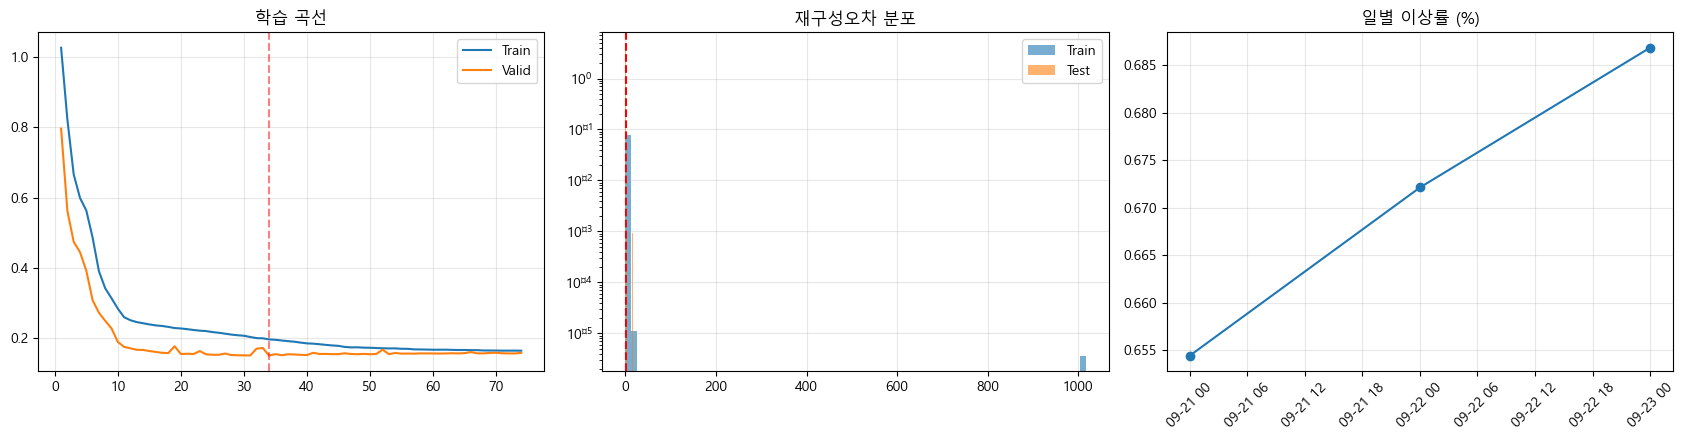

              사출  이상
Date                
2026-09-21  3056  20
2026-09-22  3422  23
2026-09-23  2912  20


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
h = pd.DataFrame(hist, columns=["ep","tr","va"])
axes[0].plot(h.ep, h.tr, label="Train"); axes[0].plot(h.ep, h.va, label="Valid")
axes[0].axvline(best_ep, color="red", ls="--", alpha=.5); axes[0].set_title("학습 곡선")
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].hist(tr_err, bins=80, alpha=.6, density=True, label="Train")
axes[1].hist(te_err, bins=80, alpha=.6, density=True, label="Test")
axes[1].axvline(TH, color="red", ls="--"); axes[1].set_yscale("log")
axes[1].set_title("재구성오차 분포"); axes[1].legend(); axes[1].grid(alpha=.3)

d = res.copy(); d["Date"] = pd.to_datetime(d["Shot_Time"]).dt.date
daily = d.groupby("Date").apply(lambda g: (g["Recon_Error"] > TH).mean()*100)
axes[2].plot(daily.index, daily.values, marker="o")
axes[2].set_title("일별 이상률 (%)"); axes[2].grid(alpha=.3)
plt.setp(axes[2].get_xticklabels(), rotation=45)
plt.tight_layout(); plt.show()
print(d.groupby("Date").agg(사출=("Recon_Error","size"),
                            이상=("Recon_Error", lambda s:(s>TH).sum())).to_string())